In [98]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [99]:
df = pd.read_csv('/content/survey.csv')

print(df.shape)

df.head()

(1259, 27)


,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


In [100]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Timestamp                  1259 non-null   object
 1   Age                        1259 non-null   int64 
 2   Gender                     1259 non-null   object
 3   Country                    1259 non-null   object
 4   state                      744 non-null    object
 5   self_employed              1241 non-null   object
 6   family_history             1259 non-null   object
 7   treatment                  1259 non-null   object
 8   work_interfere             995 non-null    object
 9   no_employees               1259 non-null   object
 10  remote_work                1259 non-null   object
 11  tech_company               1259 non-null   object
 12  benefits                   1259 non-null   object
 13  care_options               1259 non-null   object
 14  wellness

In [101]:
df.describe()

,Age
count,1.259000e+03
mean,7.942815e+07
std,2.818299e+09
min,-1.726000e+03
25%,2.700000e+01
50%,3.100000e+01
75%,3.600000e+01
max,1.000000e+11


In [102]:
df.columns

Index(['Timestamp', 'Age', 'Gender', 'Country', 'state', 'self_employed',
       'family_history', 'treatment', 'work_interfere', 'no_employees',
       'remote_work', 'tech_company', 'benefits', 'care_options',
       'wellness_program', 'seek_help', 'anonymity', 'leave',
       'mental_health_consequence', 'phys_health_consequence', 'coworkers',
       'supervisor', 'mental_health_interview', 'phys_health_interview',
       'mental_vs_physical', 'obs_consequence', 'comments'],
      dtype='object')

In [103]:
missing = df.isnull().sum()

missing.sort_values(ascending=False)

,0
comments,1095
state,515
work_interfere,264
self_employed,18
Gender,0
Timestamp,0
Age,0
family_history,0
treatment,0
no_employees,0


In [104]:
missing_percent = (df.isnull().sum()/len(df))*100

missing_percent.sort_values(ascending=False)

,0
comments,86.973789
state,40.905481
work_interfere,20.969023
self_employed,1.429706
Gender,0.000000
Timestamp,0.000000
Age,0.000000
family_history,0.000000
treatment,0.000000
no_employees,0.000000


In [105]:
df['comments'] = df['comments'].fillna('No Comment')

In [106]:
df['state'] = df['state'].fillna('Unknown')

In [107]:
df['work_interfere'] = df['work_interfere'].fillna(
    df['work_interfere'].mode()[0]
)

In [108]:
df['self_employed'] = df['self_employed'].fillna(
    df['self_employed'].mode()[0]
)

In [109]:
df.isnull().sum()

,0
Timestamp,0
Age,0
Gender,0
Country,0
state,0
self_employed,0
family_history,0
treatment,0
work_interfere,0
no_employees,0


In [110]:
print("Before:",df.shape)

df.drop_duplicates(inplace=True)

print("After:",df.shape)

Before: (1259, 27)
After: (1259, 27)


In [111]:
df['Age'].describe()

,Age
count,1.259000e+03
mean,7.942815e+07
std,2.818299e+09
min,-1.726000e+03
25%,2.700000e+01
50%,3.100000e+01
75%,3.600000e+01
max,1.000000e+11


In [112]:
df[df['Age'] > 100]

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
364,2014-08-27 15:05:21,329,Male,United States,OH,No,No,Yes,Often,6-25,...,Don't know,Maybe,No,Some of them,No,No,No,No,No,No Comment
390,2014-08-27 15:24:47,99999999999,All,Zimbabwe,Unknown,Yes,Yes,Yes,Often,1-5,...,Very difficult,Yes,Yes,No,No,Yes,No,No,Yes,No Comment


In [113]:
df[df['Age'] < 10]

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
143,2014-08-27 12:39:14,-29,Male,United States,MN,No,No,No,Sometimes,More than 1000,...,Don't know,No,No,Some of them,Yes,No,No,Don't know,No,No Comment
715,2014-08-28 10:07:53,-1726,male,United Kingdom,Unknown,No,No,Yes,Sometimes,26-100,...,Somewhat difficult,Yes,No,No,No,No,Maybe,Don't know,No,No Comment
734,2014-08-28 10:35:55,5,Male,United States,OH,No,No,No,Sometimes,100-500,...,Somewhat easy,No,No,Yes,Yes,No,No,Yes,No,We had a developer suffer from depression and ...
989,2014-08-29 09:10:58,8,A little about you,"Bahamas, The",IL,Yes,Yes,Yes,Often,1-5,...,Very easy,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,
1127,2014-08-30 20:55:11,-1,p,United States,AL,Yes,Yes,Yes,Often,1-5,...,Very easy,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,password: testered


In [114]:
df = df[(df['Age']>=18) & (df['Age']<=65)]

In [115]:
df['Gender'].value_counts().head(50)

,count
Gender,
Male,612
male,204
Female,120
M,116
female,62
F,38
m,34
f,15
Make,4


In [116]:
def clean_gender(g):

    g = str(g).lower()

    if 'male' in g or g in ['m','man']:
        return 'Male'

    elif 'female' in g or g in ['f','woman']:
        return 'Female'

    else:
        return 'Other'

In [117]:
df['Gender'] = df['Gender'].apply(clean_gender)

In [118]:
df['Gender'].value_counts()

,count
Gender,
Male,1169
Female,57
Other,24


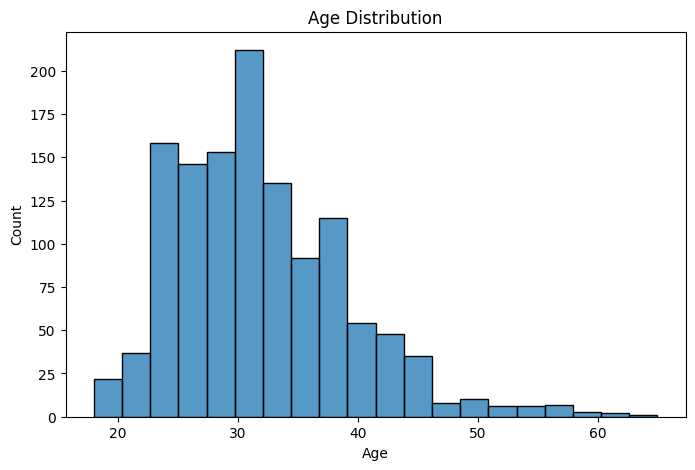

In [119]:
plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=20)

plt.title('Age Distribution')

plt.show()

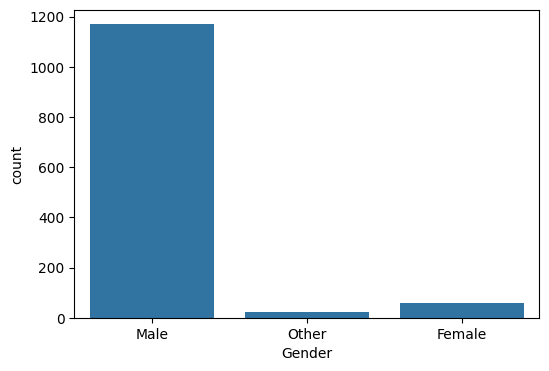

In [120]:
plt.figure(figsize=(6,4))

sns.countplot(x='Gender',data=df)

plt.show()

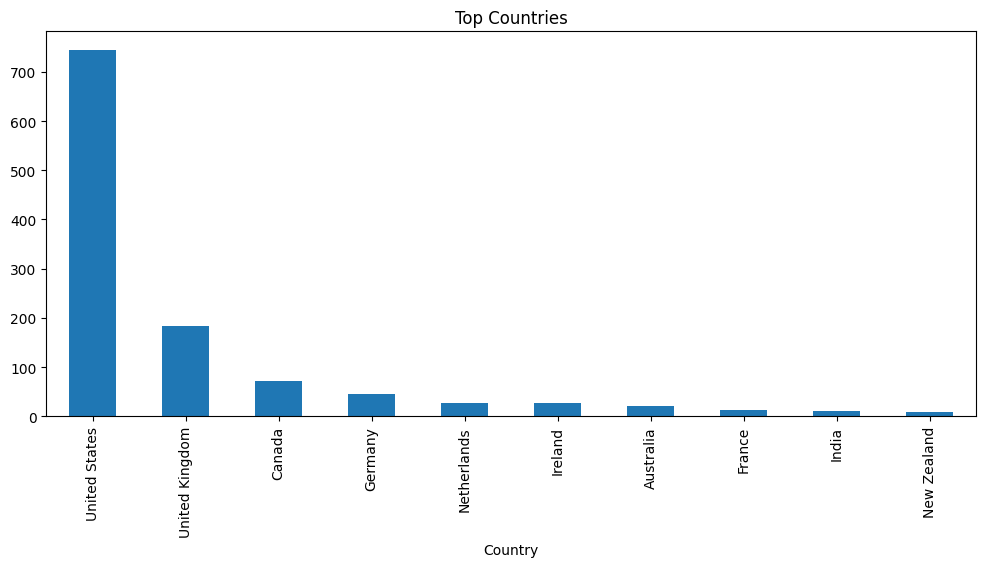

In [121]:
plt.figure(figsize=(12,5))

df['Country'].value_counts().head(10).plot(kind='bar')

plt.title('Top Countries')

plt.show()

In [122]:
df['treatment'].value_counts()

,count
treatment,
Yes,631
No,619


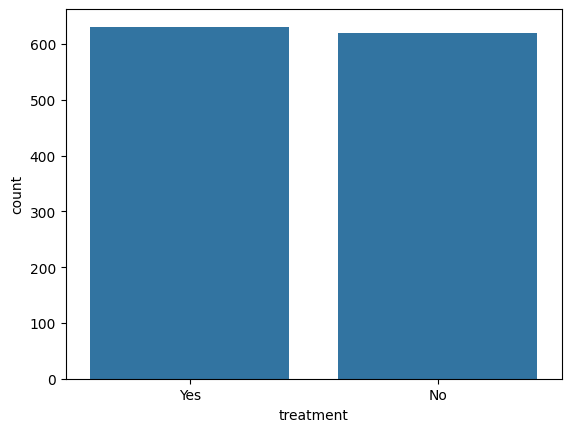

In [123]:
sns.countplot(x='treatment',data=df)

plt.show()

In [124]:
pd.crosstab(
    df['Gender'],
    df['treatment']
)

treatment,No,Yes
Gender,,
Female,20,37
Male,591,578
Other,8,16


<Axes: xlabel='Gender'>

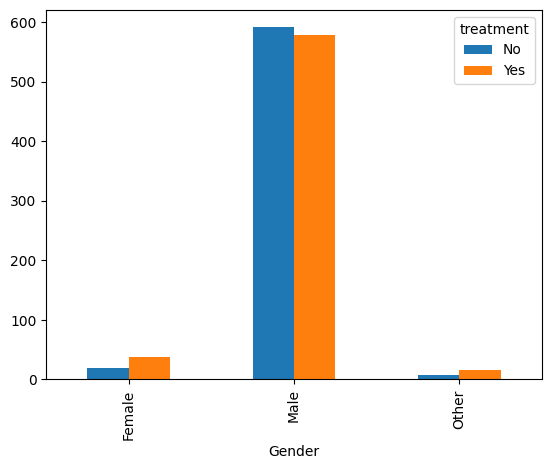

In [125]:
pd.crosstab(
    df['Gender'],
    df['treatment']
).plot(kind='bar')

In [126]:
pd.crosstab(
    df['family_history'],
    df['treatment']
)

treatment,No,Yes
family_history,,
No,492,270
Yes,127,361


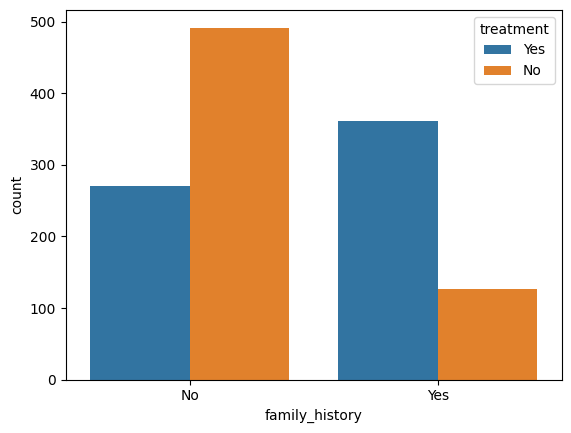

In [127]:
sns.countplot(
    x='family_history',
    hue='treatment',
    data=df
)

plt.show()

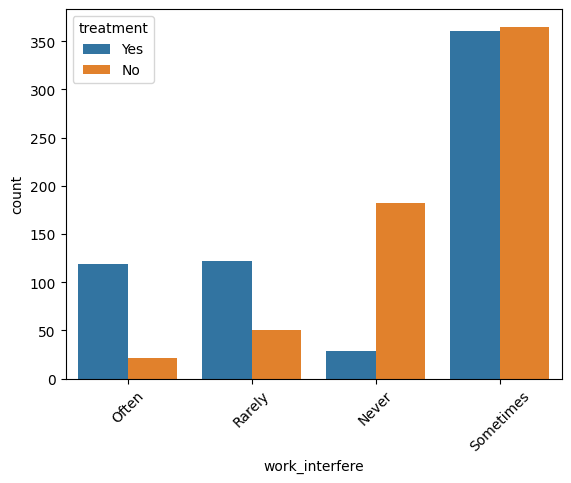

In [128]:
sns.countplot(
    x='work_interfere',
    hue='treatment',
    data=df
)

plt.xticks(rotation=45)

plt.show()

In [129]:
df2 = df.copy()

binary_cols = [
'treatment',
'family_history',
'remote_work',
'tech_company'
]

for col in binary_cols:

    df2[col] = df2[col].map({
        'Yes':1,
        'No':0
    })

In [130]:
!pip install nltk

In [131]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [132]:
import re

from nltk.corpus import stopwords

from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words('english'))

In [133]:
def clean_text(text):

    text = str(text).lower()

    text = re.sub(r'http\S+','',text)

    text = re.sub(r'[^a-zA-Z ]','',text)

    words = word_tokenize(text)

    words = [
        word
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [134]:
df['clean_comments'] = df['comments'].apply(clean_text)

In [135]:
from collections import Counter

In [136]:
all_words = " ".join(df['clean_comments'])

freq = Counter(all_words.split())

freq.most_common(20)

[('comment', 1089),
 ('health', 113),
 ('mental', 101),
 ('work', 47),
 ('dont', 44),
 ('employer', 41),
 ('issues', 37),
 ('would', 34),
 ('people', 30),
 ('company', 29),
 ('im', 28),
 ('know', 25),
 ('depression', 20),
 ('ive', 20),
 ('questions', 19),
 ('feel', 19),
 ('insurance', 18),
 ('get', 17),
 ('job', 16),
 ('coworkers', 15)]

In [137]:
!pip install wordcloud

In [138]:
from wordcloud import WordCloud

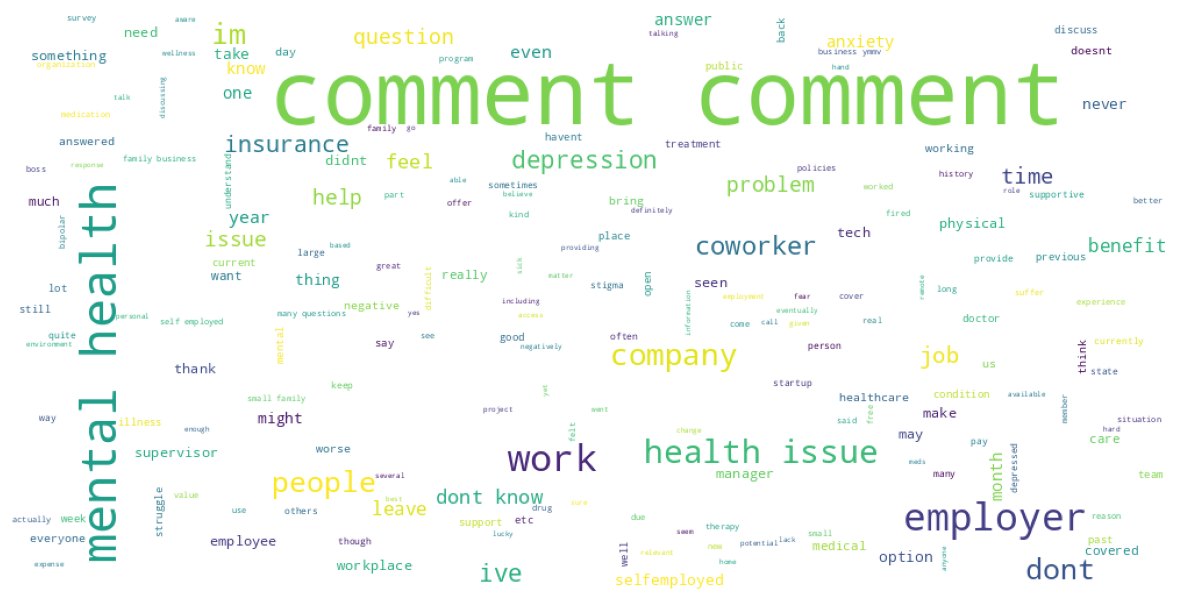

In [139]:
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(all_words)

plt.figure(figsize=(15,8))

plt.imshow(wordcloud)

plt.axis('off')

plt.show()

In [140]:
df.to_csv(
    'cleaned_survey.csv',
    index=False
)

In [141]:
import pandas as pd

df = pd.read_csv('/content/cleaned_survey.csv')

df.head()

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments,clean_comments
0,2014-08-27 11:29:31,37,Male,United States,IL,No,No,Yes,Often,6-25,...,No,No,Some of them,Yes,No,Maybe,Yes,No,No Comment,comment
1,2014-08-27 11:29:37,44,Male,United States,IN,No,No,No,Rarely,More than 1000,...,Maybe,No,No,No,No,No,Don't know,No,No Comment,comment
2,2014-08-27 11:29:44,32,Male,Canada,Unknown,No,No,No,Rarely,6-25,...,No,No,Yes,Yes,Yes,Yes,No,No,No Comment,comment
3,2014-08-27 11:29:46,31,Male,United Kingdom,Unknown,No,Yes,Yes,Often,26-100,...,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,No Comment,comment
4,2014-08-27 11:30:22,31,Male,United States,TX,No,No,No,Never,100-500,...,No,No,Some of them,Yes,Yes,Yes,Don't know,No,No Comment,comment


In [142]:
df['treatment'].value_counts()

,count
treatment,
Yes,631
No,619


In [143]:
df = df[df['clean_comments'].str.strip() != '']

df.shape

(1250, 28)

In [144]:
df['clean_comments'] = df['clean_comments'].fillna('').astype(str)

df = df[df['clean_comments'].str.strip() != '']

print("Null Values:", df['clean_comments'].isnull().sum())

print("Shape:", df.shape)

Null Values: 0
Shape: (1249, 28)


In [145]:
X = df['clean_comments']

y = df['treatment']

In [146]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(999,)
(250,)


In [147]:
print(X_train.isnull().sum())
print(X_test.isnull().sum())

0
0


In [148]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

In [149]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()

nb.fit(X_train_tfidf, y_train)

pred_nb = nb.predict(X_test_tfidf)

In [150]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000
)

lr.fit(X_train_tfidf, y_train)

pred_lr = lr.predict(X_test_tfidf)

In [151]:
from sklearn.svm import LinearSVC

svm = LinearSVC()

svm.fit(X_train_tfidf, y_train)

pred_svm = svm.predict(X_test_tfidf)

In [152]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

In [153]:
print("NAIVE BAYES")

print(classification_report(
    y_test,
    pred_nb
))

print("Accuracy:",
      accuracy_score(
          y_test,
          pred_nb
      ))

NAIVE BAYES
              precision    recall  f1-score   support

          No       0.54      0.96      0.69       124
         Yes       0.82      0.18      0.30       126

    accuracy                           0.57       250
   macro avg       0.68      0.57      0.49       250
weighted avg       0.68      0.57      0.49       250

Accuracy: 0.568


In [154]:
print("LOGISTIC REGRESSION")

print(classification_report(
    y_test,
    pred_lr
))

print("Accuracy:",
      accuracy_score(
          y_test,
          pred_lr
      ))

LOGISTIC REGRESSION
              precision    recall  f1-score   support

          No       0.53      0.93      0.67       124
         Yes       0.73      0.19      0.30       126

    accuracy                           0.56       250
   macro avg       0.63      0.56      0.49       250
weighted avg       0.63      0.56      0.49       250

Accuracy: 0.556


In [155]:
print("SVM")

print(classification_report(
    y_test,
    pred_svm
))

print("Accuracy:",
      accuracy_score(
          y_test,
          pred_svm
      ))

SVM
              precision    recall  f1-score   support

          No       0.52      0.95      0.68       124
         Yes       0.76      0.15      0.25       126

    accuracy                           0.55       250
   macro avg       0.64      0.55      0.46       250
weighted avg       0.64      0.55      0.46       250

Accuracy: 0.548


In [156]:
models = ['NB','LR','SVM']

acc = [

accuracy_score(y_test,pred_nb),

accuracy_score(y_test,pred_lr),

accuracy_score(y_test,pred_svm)

]

comparison = pd.DataFrame({

'Model':models,

'Accuracy':acc

})

comparison

,Model,Accuracy
0,NB,0.568
1,LR,0.556
2,SVM,0.548


In [157]:
best_model = svm

In [158]:
from sklearn.metrics import confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt

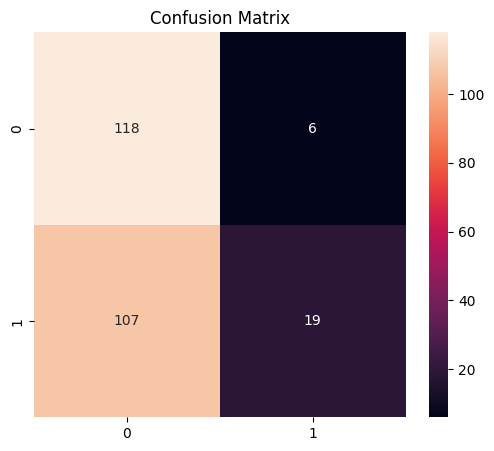

In [159]:
cm = confusion_matrix(
    y_test,
    pred_svm
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")

plt.show()

In [160]:
df['predicted_treatment'] = best_model.predict(
    tfidf.transform(df['clean_comments'])
)

In [161]:
risk_df = df[
    df['predicted_treatment'] == 'Yes'
]

In [162]:
risk_df.shape

(104, 29)

In [163]:
risk_df['Gender'].value_counts()

,count
Gender,
Male,96
Female,5
Other,3


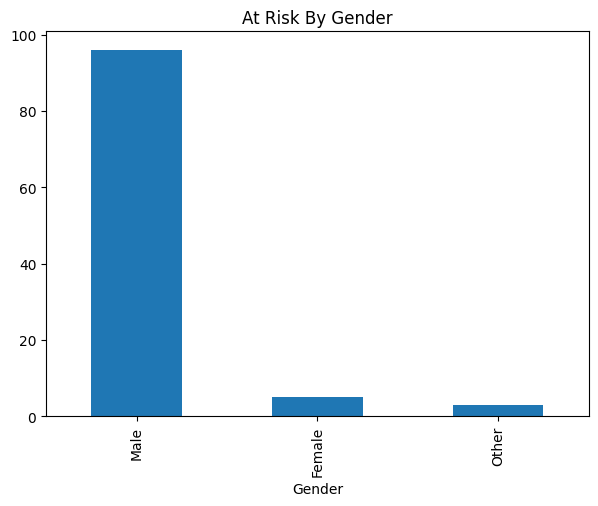

In [164]:
plt.figure(figsize=(7,5))

risk_df['Gender'].value_counts().plot(
    kind='bar'
)

plt.title("At Risk By Gender")

plt.show()

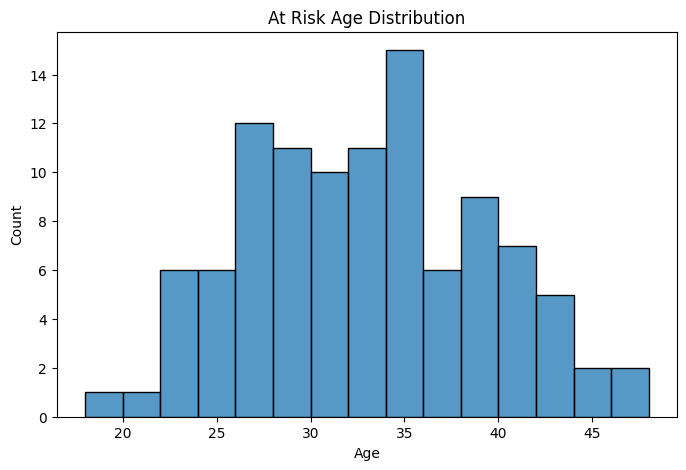

In [165]:
plt.figure(figsize=(8,5))

sns.histplot(
    risk_df['Age'],
    bins=15
)

plt.title(
    "At Risk Age Distribution"
)

plt.show()

In [166]:
risk_df['Country'].value_counts().head(10)

,count
Country,
United States,65
United Kingdom,19
Canada,5
Germany,5
Australia,3
Netherlands,2
Portugal,1
Belgium,1
New Zealand,1


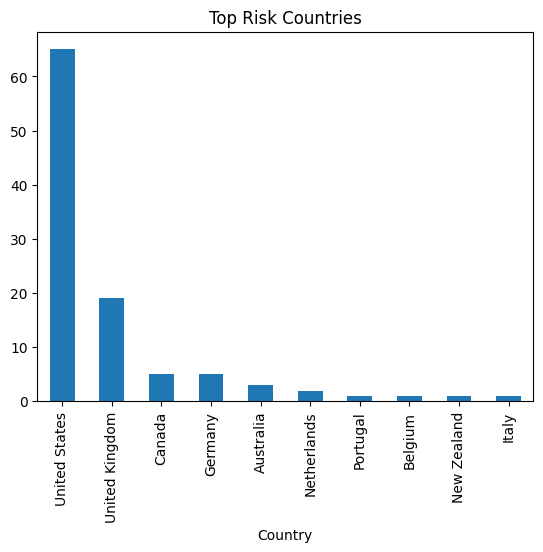

In [167]:
risk_df['Country'].value_counts().head(10).plot(
    kind='bar'
)

plt.title(
    "Top Risk Countries"
)

plt.show()

In [168]:
pd.crosstab(

df['family_history'],

df['predicted_treatment']

)

predicted_treatment,No,Yes
family_history,,
No,722,39
Yes,423,65


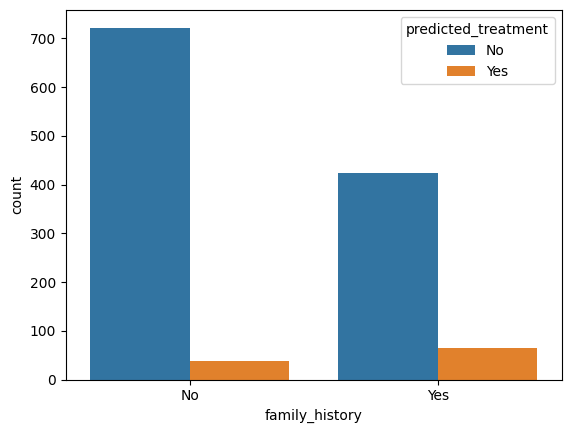

In [169]:
sns.countplot(

x='family_history',

hue='predicted_treatment',

data=df

)

plt.show()

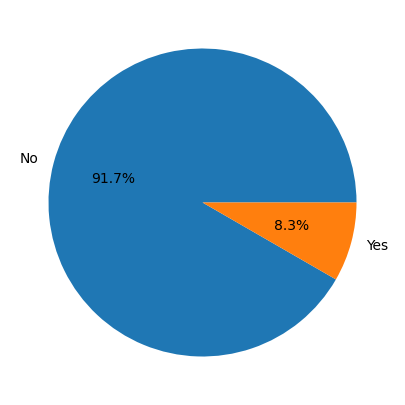

In [170]:
plt.figure(figsize=(6,5))

df['predicted_treatment'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel('')

plt.show()

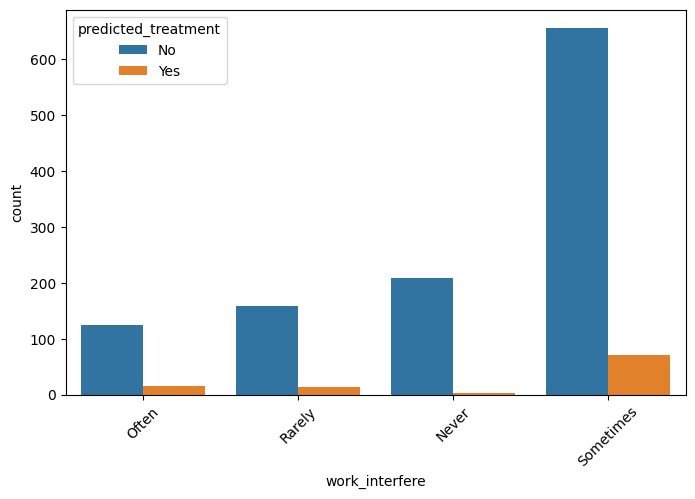

In [171]:
plt.figure(figsize=(8,5))

sns.countplot(

x='work_interfere',

hue='predicted_treatment',

data=df

)

plt.xticks(rotation=45)

plt.show()

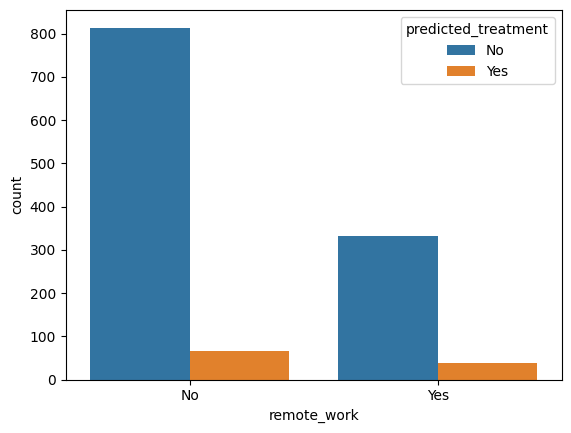

In [172]:
sns.countplot(

x='remote_work',

hue='predicted_treatment',

data=df

)

plt.show()

In [173]:
df.to_csv(

'mental_health_predictions.csv',

index=False

)

In [174]:
import pickle

In [175]:
pickle.dump(

best_model,

open(
    'mental_health_model.pkl',
    'wb'
)

)

In [176]:
pickle.dump(

tfidf,

open(
    'tfidf_vectorizer.pkl',
    'wb'
)

)

In [177]:
sample = [

"I feel stressed and anxious at work"

]

sample_vec = tfidf.transform(sample)

prediction = best_model.predict(sample_vec)

print(prediction)

['Yes']


In [178]:
print(comparison)

  Model  Accuracy
0    NB     0.568
1    LR     0.556
2   SVM     0.548


HR Recommendations

1. Conduct regular mental health awareness programs.

2. Provide confidential counseling and employee assistance programs.

3. Monitor employees reporting high work interference.

4. Encourage flexible work arrangements and work-life balance.

5. Train managers to identify early signs of stress and burnout.

6. Implement anonymous feedback mechanisms.

7. Conduct quarterly employee wellness surveys.

8. Develop mental health support policies across all departments.

Project Conclusion

This project developed a Mental Health Sentiment Analyzer using NLP and Machine Learning techniques.

The survey dataset was cleaned and preprocessed, followed by exploratory data analysis to identify workplace wellness trends.

TF-IDF vectorization was applied to textual responses and multiple machine learning models including Naive Bayes, Logistic Regression, and Support Vector Machine were trained and evaluated.

The best-performing model was selected and used to identify employees potentially requiring mental health treatment.

The analysis highlighted relationships between treatment seeking behavior, family history, work interference, age, gender, and location.

The developed solution can assist HR teams in identifying at-risk employee groups and implementing proactive wellness initiatives.

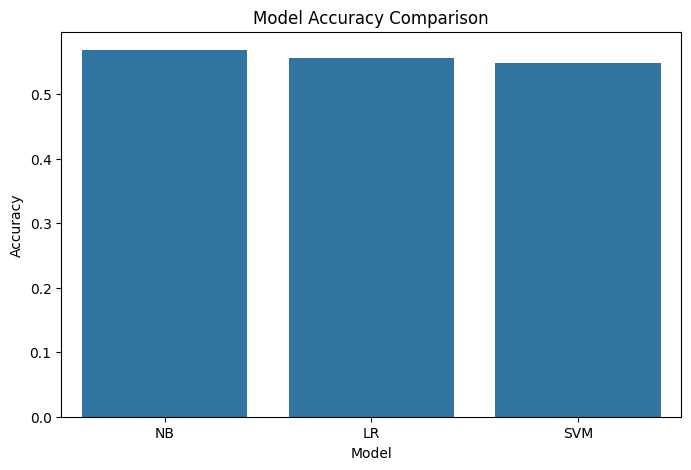

In [179]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=comparison
)

plt.title('Model Accuracy Comparison')

plt.show()

At-Risk Cohort Findings

1. Employees reporting work interference showed a higher likelihood of seeking treatment.

2. Employees with a family history of mental health conditions demonstrated higher treatment rates.

3. Certain age groups exhibited greater mental health risk indicators.

4. Mental health concerns varied across countries and demographic groups.

5. Workplace factors significantly influenced employee well-being outcomes.

In [180]:
from textblob import TextBlob

def get_sentiment(text):

    polarity = TextBlob(text).sentiment.polarity

    if polarity > 0:
        return "Positive"

    elif polarity < 0:
        return "Negative"

    else:
        return "Neutral"

df['sentiment'] = df['clean_comments'].apply(get_sentiment)

df['sentiment'].value_counts()

,count
sentiment,
Neutral,1104
Positive,78
Negative,67


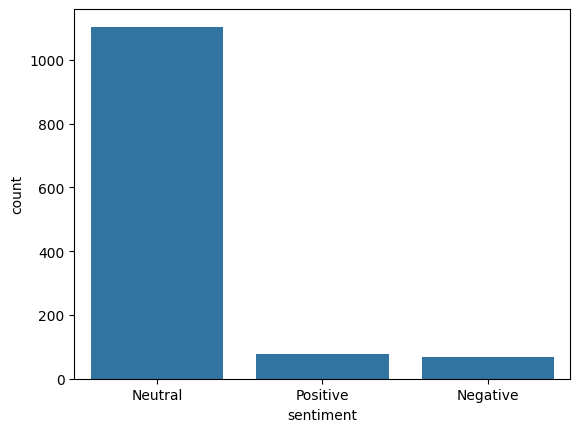

In [181]:
sns.countplot(
    x='sentiment',
    data=df
)

plt.show()